   Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
0            2  115.863387      56.410731      24.336736   94.385783   
1            2   92.490122      70.615520      23.443591  138.652426   
2            1   88.141469      63.262618      23.404364  149.358082   
3            2  108.453101      67.793632      20.751580  108.751638   
4            1  127.849443      94.725685      22.603078   25.269987   

         BMI  DiabetesPedigreeFunction        Age  Diagnosis  
0  26.455940                  0.272682  20.100494          0  
1  23.910167                  0.665160  44.912281          0  
2  21.948250                  0.676022  48.247873          1  
3  24.209304                  0.289636  42.749868          0  
4  32.997477                  0.601315  32.797789          0  
Confusion Matrix:
 [[177  31]
 [ 83   9]]

Accuracy Score: 0.62

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.85      0.76  

<Figure size 2000x2000 with 0 Axes>

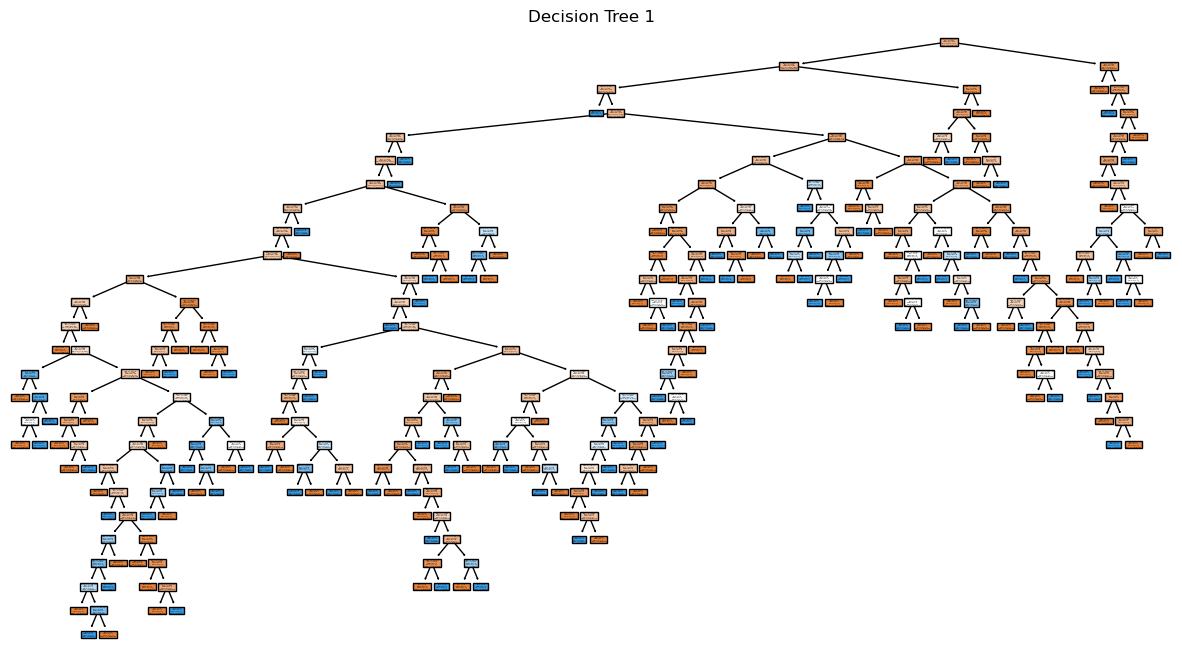

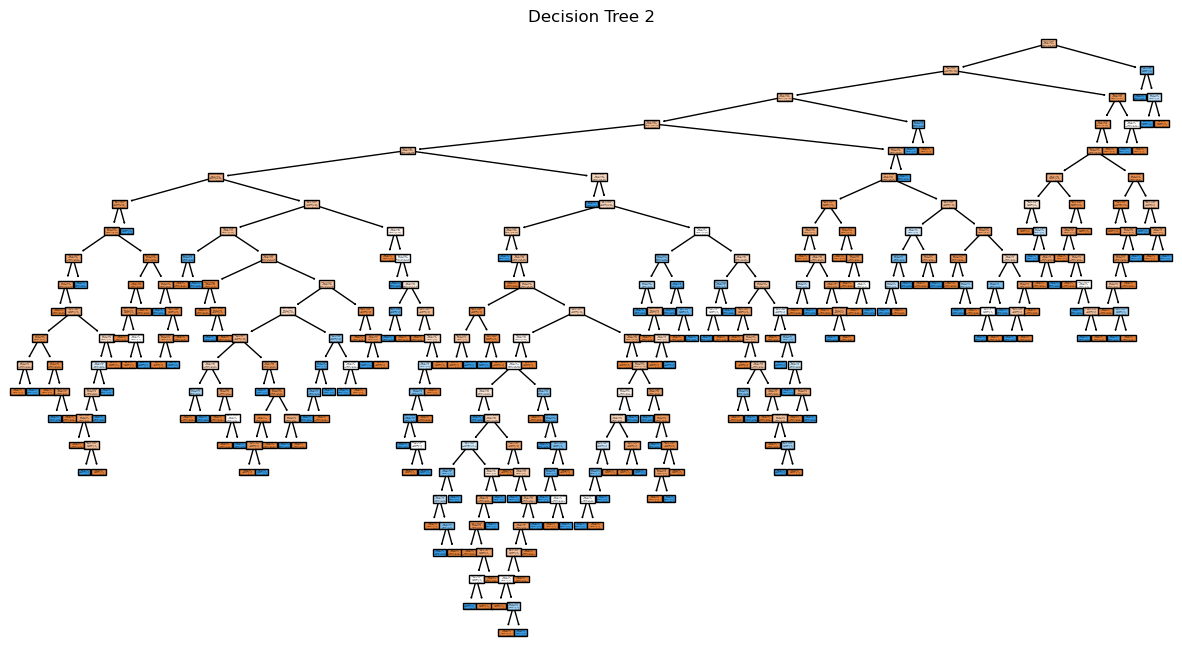

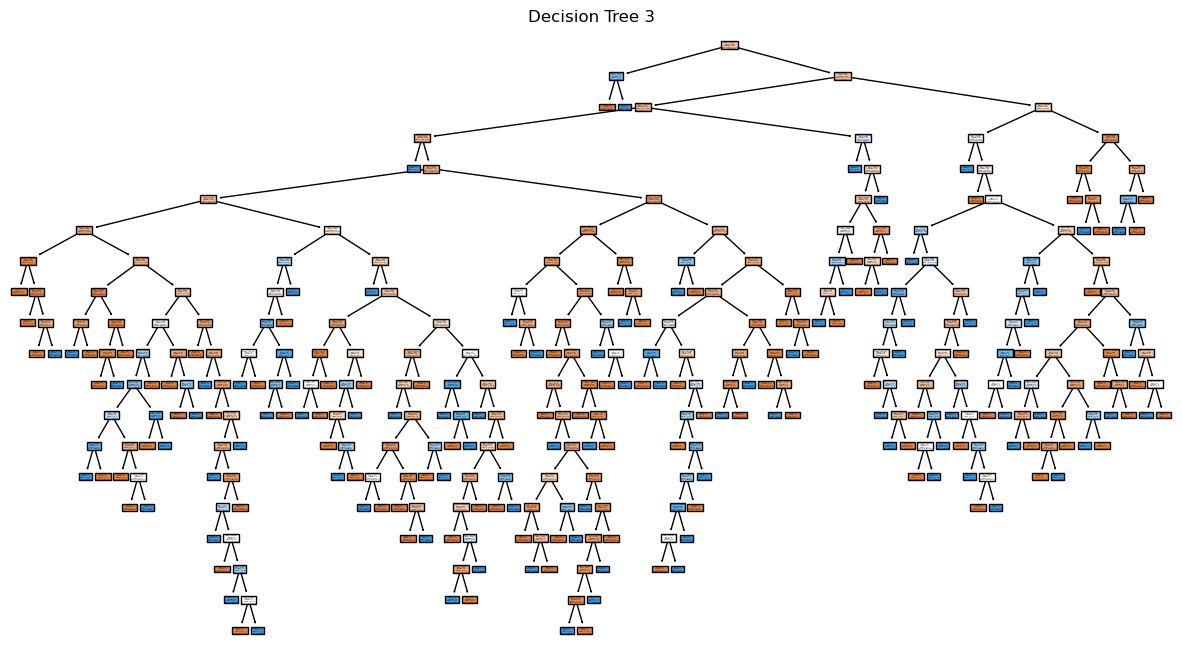

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Load the dataset
file_path = 'Diabetes_prediction.csv'  
data = pd.read_csv(file_path)

# Display dataset info
print(data.head())

# Select 2-3 features and the target column
X = data[['Glucose', 'BMI', 'Age']]  
y = data['Diagnosis']                

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a Random Forest Classifier
rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X_train, y_train)

# Predict on the test set
y_pred = rf.predict(X_test)

# Evaluate the model
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Confusion Matrix:\n", conf_matrix)
print("\nAccuracy Score:", accuracy)
print("\nClassification Report:\n", class_report)

# Visualize individual trees from the Random Forest
plt.figure(figsize=(20, 20))
for i, estimator in enumerate(rf.estimators_):
    if i == 3:  # Visualize up to 3 trees for clarity
        break
    plt.figure(figsize=(15, 8))
    plot_tree(estimator, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'], filled=True)
    plt.title(f"Decision Tree {i+1}")
    plt.show()
